# Behaviour Analyses — Mixed Models

In [8]:
from pymer4.models import lmer, glmer
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import warnings

sns.set(font_scale=1.3, style="ticks")
plt.rcParams["figure.dpi"] = 100


In [9]:
# load data
data_path = "/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv"
all_df = pd.read_csv(data_path)
print(f"Dataset loaded: {all_df.shape[0]} rows, {all_df.shape[1]} columns")
all_df.head(3)

Dataset loaded: 6600 rows, 36 columns


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [10]:
# preprocessing 
df = all_df.copy()

df["cond"]    = df["cond"].replace({-1: 0}) # convertimos la condicion -1 a 0 para que sea mas facil de interpretar
df["correct"] = df["correct"].replace({-1: 0}) # convertimos la respuesta incorrecta -1 a 0 para que sea mas facil de interpretar
df["switch"]  = (df["deci"] != df["deci-1"]).astype(int) # creamos una nueva columna "switch" que indica si la decision actual es diferente a la anterior (1) o no (0)

median_confi   = df["confi"].median() # calculamos la mediana de la confianza para dividir en alta y baja
df["conf_lvl"] = np.where(df["confi"] >= median_confi, "H", "L") # creamos una nueva columna "conf_lvl" que indica si la confianza es alta (H) o baja (L) segun la mediana

df = df.sort_values(["subj", "nblock", "ntrial", "nrep"]).reset_index(drop=True) # ordenamos el dataframe por sujeto, bloque, trial y repeticion para asegurar que las filas estan en el orden correcto 
df["confi-1"]   = df.groupby(["subj", "nblock", "ntrial"])["confi"].shift(1) # creamos una nueva columna "confi-1" que contiene la confianza del trial anterior
df["correct-1"] = df["corr-1"] # creamos una nueva columna "correct-1" que contiene la respuesta correcta del trial anterior

df["nrep_f"]    = df["nrep"].astype(str) 
df["is_repeat"] = (df["trial_type"] == "repeat").astype(int) # creamos una nueva columna "is_repeat" que indica si el trial es de tipo "repeat" (1) o no (0)
df["deci1_c"]   = df["deci-1"] - 0.5 # creamos una nueva columna "deci1_c" que contiene la decision del trial anterior centrada en 0 (restando 0.5 para que tome valores -0.5 o 0.5) --> asi el valor 0 representa el punto medio entre las dos decisiones posibles
df["rDV_z"]     = df.groupby("subj")["rDV"].transform( # creamos una nueva columna "rDV_z" que contiene la rDV estandarizada para cada sujeto
    lambda x: (x - x.mean()) / x.std()) # no tiene unidades concretas, sino que te dice cuantas desviaciones esta ese valor por encima o por debajo de la media
df["metad_z"]   = (df["metad"] - df["metad"].mean()) / df["metad"].std() # creamos una nueva columna "metad_z" que contiene el metad estandarizado (centrado en 0 y con desviacion estandar 1) para todo el dataset (no por sujeto, porque el metad ya es una medida relativa que compara la confianza con la precision de las respuestas, asi que no tiene sentido estandarizarlo por sujeto)

print(f"cond      → {sorted(df['cond'].unique())}")
print(f"correct   → {sorted(df['correct'].unique())}")
print(f"switch    → {sorted(df['switch'].unique())}")
print(f"is_repeat → {sorted(df['is_repeat'].unique())}")
print(f"\nNaN confi-1  : {df['confi-1'].isna().sum()}")
print(f"NaN correct-1: {df['correct-1'].isna().sum()}")
print(f"\nTotal rows   : {len(df)}")
print(f"Participants: {df['subj'].nunique()}")

cond      → [np.int64(0), np.int64(1)]
correct   → [np.int64(0), np.int64(1)]
switch    → [np.int64(0), np.int64(1)]
is_repeat → [np.int64(0), np.int64(1)]

NaN confi-1  : 2200
NaN correct-1: 0

Total rows   : 6600
Participants: 25


In [11]:
# RT filter --> eliminamos los trials con tiempos de respuesta (RT) muy altos, que pueden ser indicativos de distracciones o errores = outliers
def RT_filter(x, sd=4):
    return x[x["RT"] < x["RT"].mean() + sd * x["RT"].std()] # mantenemos solo los trials cuyo RT es menor que la media + 4 veces la std del RT para ese sujeto

df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)

print(f"Trials before filter : {len(df)}")
print(f"Trials after filter  : {len(df_rt)}")
print(f"Trials removed       : {len(df)-len(df_rt)} ({(len(df)-len(df_rt))/len(df)*100:.1f}%)")

Trials before filter : 6600
Trials after filter  : 6537
Trials removed       : 63 (1.0%)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_79342/63519787.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)


In [12]:
# LMM on RT 
# Model: RT ~ nrep * is_repeat + (1|subj) --> queremos ver si el tiempo de respuesta (RT) se ve afectado por el numero de repeticion (nrep), el tipo de trial (is_repeat) y su interaccion, mientras controlamos por la variabilidad entre sujetos (1|subj)
# es decir, si ves el mismo estimulo varias veces (nrep) o si es un trial repeat, respondes mas rapido?
md_rt = lmer("RT ~ nrep * is_repeat + (1|subj)",
             data=pl.from_pandas(df_rt))
md_rt.fit()

coefs_rt = md_rt.result_fit  
print(coefs_rt)
print(f"\ngroup var (between participant variance): {md_rt.ranef_var['estimate'][0]:.4f}")

shape: (4, 8)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬────────────┬────────────┐
│ term       ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ t_stat    ┆ df         ┆ p_value    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---        │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64        │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪════════════╡
│ (Intercept ┆ 1.40583   ┆ 0.047071  ┆ 1.309678  ┆ 1.501981  ┆ 29.866448 ┆ 29.847829  ┆ 8.6031e-24 │
│ )          ┆           ┆           ┆           ┆           ┆           ┆            ┆            │
│ nrep       ┆ -0.010209 ┆ 0.013056  ┆ -0.035803 ┆ 0.015385  ┆ -0.781946 ┆ 6509.01437 ┆ 0.434275   │
│            ┆           ┆           ┆           ┆           ┆           ┆ 7          ┆            │
│ is_repeat  ┆ -0.026766 ┆ 0.023841  ┆ -0.073503 ┆ 0.019971  ┆ -1.122671 ┆ 65

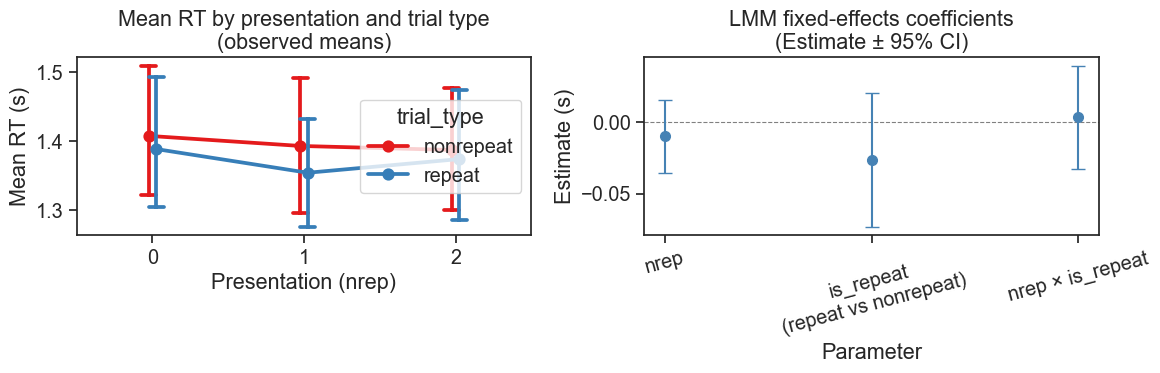


Fixed effects interpretation:
  nrep                      β=-0.0102  p=0.4343  → n.s.
  is_repeat                 β=-0.0268  p=0.2616  → n.s.
  nrep:is_repeat            β=+0.0031  p=0.8682  → n.s.


In [13]:
# Plot RT 
coefs_rt_pd = coefs_rt.to_pandas()
coefs_rt_pd = coefs_rt_pd[coefs_rt_pd["term"] != "(Intercept)"].copy()

avg_rt = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["RT"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_rt, x="nrep", y="RT", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Mean RT by presentation and trial type\n(observed means)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("Mean RT (s)")

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_rt_pd)),
    y=coefs_rt_pd["estimate"],
    yerr=[coefs_rt_pd["estimate"] - coefs_rt_pd["conf_low"],
          coefs_rt_pd["conf_high"] - coefs_rt_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("LMM fixed-effects coefficients\n(Estimate ± 95% CI)")
axes[1].set_xlabel("Parameter")
axes[1].set_ylabel("Estimate (s)")
axes[1].set_xticks(range(len(coefs_rt_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
plt.tight_layout()
plt.show()

print("\nFixed effects interpretation:")
for _, row in coefs_rt_pd.iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [14]:
# GLMM on accuracy 
# Model: correct ~ nrep * is_repeat + (1|subj) --> mejora la accuracy con cada presentacion o si es un trial repeat?
# es decir, si ves el mismo estimulo varias veces (nrep) o si es un trial repeat, aciertas mas?

md_correct = glmer("correct ~ nrep * is_repeat + (1|subj)", # usamos glmer porque la variable "correct" es binaria (0 o 1) y especificamos family="binomial" para indicar que se trate como una probabilidad de acierto en lugar de un valor continuo
                   data=pl.from_pandas(df_rt),
                   family="binomial")
md_correct.fit()

coefs_correct = md_correct.result_fit
print(coefs_correct)

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ 0.992222  ┆ 0.06429   ┆ 0.866217  ┆ 1.118227  ┆ 15.433632 ┆ inf ┆ 9.7240e-54 │
│ nrep           ┆ 0.041651  ┆ 0.048804  ┆ -0.054003 ┆ 0.137305  ┆ 0.853429  ┆ inf ┆ 0.393421   │
│ is_repeat      ┆ -0.081489 ┆ 0.087597  ┆ -0.253176 ┆ 0.090197  ┆ -0.930276 ┆ inf ┆ 0.352228   │
│ nrep:is_repeat ┆ -0.015072 ┆ 0.068206  ┆ -0.148754 ┆ 0.11861   ┆ -0.220971 ┆ inf ┆ 0.825115   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘


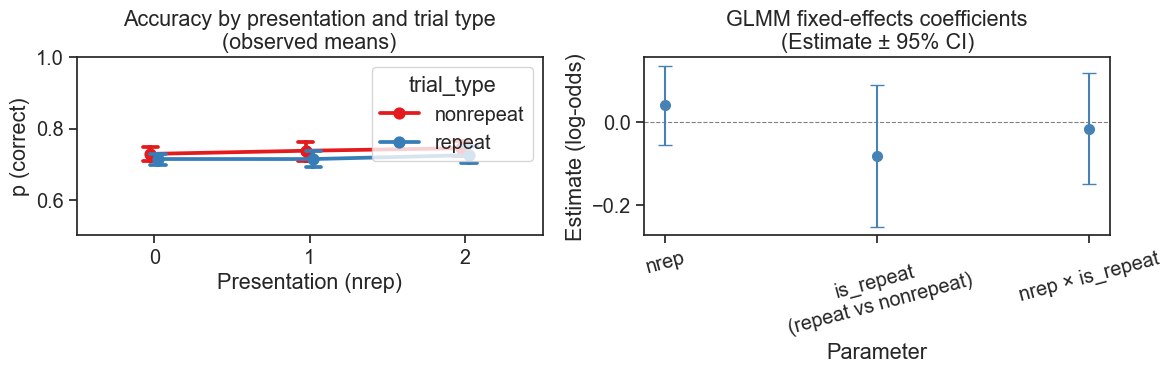


Interpretation (log-odds):
  nrep                      β=+0.0417  p=0.3934  → n.s.
  is_repeat                 β=-0.0815  p=0.3522  → n.s.
  nrep:is_repeat            β=-0.0151  p=0.8251  → n.s.


In [15]:
# plot accuracy 
coefs_correct_pd = coefs_correct.to_pandas()
coefs_correct_pd = coefs_correct_pd[coefs_correct_pd["term"] != "(Intercept)"].copy()
avg_correct = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["correct"].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.pointplot(data=avg_correct, x="nrep", y="correct", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Accuracy by presentation and trial type\n(observed means)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p (correct)")
axes[0].set_ylim(0.5, 1.0)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_correct_pd)),
    y=coefs_correct_pd["estimate"],
    yerr=[coefs_correct_pd["estimate"] - coefs_correct_pd["conf_low"],
          coefs_correct_pd["conf_high"] - coefs_correct_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("GLMM fixed-effects coefficients\n(Estimate ± 95% CI)")
axes[1].set_xticks(range(len(coefs_correct_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_xlabel("Parameter")
axes[1].set_ylabel("Estimate (log-odds)")
plt.tight_layout()
plt.show()
print("\nInterpretation (log-odds):")
for _, row in coefs_correct_pd.iterrows():
    sig = "SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Psychometric GLMM: deci ~ rDV_z * nrep_f + (1|subj)  [nrep categorical]
shape: (6, 8)
┌───────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term          ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---           ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str           ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞═══════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept)   ┆ 0.404122  ┆ 0.131598  ┆ 0.146196  ┆ 0.662049  ┆ 3.070894  ┆ inf ┆ 0.002134    │
│ rDV_z         ┆ 1.326578  ┆ 0.060841  ┆ 1.207332  ┆ 1.445825  ┆ 21.803904 ┆ inf ┆ 2.1305e-105 │
│ nrep_f1       ┆ -0.046982 ┆ 0.074813  ┆ -0.193613 ┆ 0.099649  ┆ -0.627995 ┆ inf ┆ 0.530007    │
│ nrep_f2       ┆ -0.037668 ┆ 0.07535   ┆ -0.185351 ┆ 0.110015  ┆ -0.499911 ┆ inf ┆ 0.617138    │
│ rDV_z:nrep_f1 ┆ 0.06535   ┆ 0.

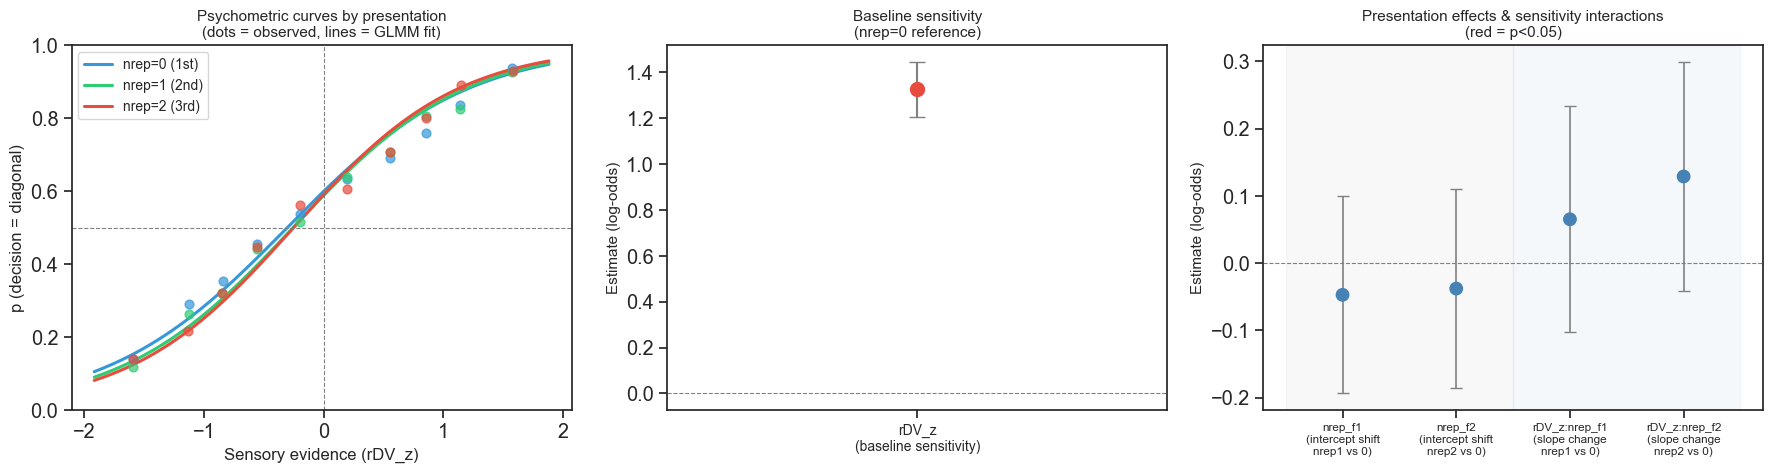


Sensitivity interactions (rDV_z slope change vs nrep=0):
  rDV_z:nrep_f1: β=+0.0654  p=0.4458  → n.s. → no significant change
  rDV_z:nrep_f2: β=+0.1290  p=0.1379  → n.s. → no significant change


In [16]:
# psychometric curves by presentation (nrep) --> relacion entre la evidencia sensorial (rDV_z) y la probabilidad de decidir "diagonal" (deci=1), separada por numero de presentacion (nrep)
from scipy.special import expit  # sigmoid

n_bins = 10
df_rt["rDV_bin"] = pd.qcut(df_rt["rDV_z"], q=n_bins, labels=False, duplicates="drop") # creamos una nueva columna "rDV_bin" que divide la rDV_z en 10 bins iguales y asigna un numero de bin (0 a 9) a cada fila segun el valor de rDV_z. Si hay valores duplicados que impiden crear bins iguales, se eliminan con duplicates="drop".

psy_data = df_rt.groupby(["subj", "nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("deci", "mean"), # para cada sujeto, numero de presentacion (nrep) y bin de rDV_z (rDV_bin), calculamos la probabilidad media de decidir "diagonal" (deci=1)
    rDV_mean=("rDV_z", "mean")
)
psy_avg = psy_data.groupby(["nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("p_deci", "mean"), # promediando entre sujetos, calculamos la probabilidad media de decidir "diagonal" (deci=1) para cada numero de presentacion (nrep) y bin de rDV_z (rDV_bin) 
    rDV_mean=("rDV_mean", "mean")
)

# GLMM with nrep as CATEGORICAL factor 
df_psy = df_rt.copy()
df_psy["nrep_f"] = pd.Categorical(df_psy["nrep"].astype(str),
                                    categories=["0", "1", "2"], # definimos nrep como factor categorico con 3 niveles (0, 1, 2) en lugar de asumir una relacion lineal entre nrep y la decision
                                    ordered=False)

# ajustamos un GLMM para modelar la probabilidad de decidir "diagonal" (deci=1) en funcion de la evidencia sensorial (rDV_z), el numero de presentacion (nrep_f) y su interaccion, mientras controlamos por la variabilidad entre sujetos (1|subj)
md_psy = glmer( 
    "deci ~ rDV_z * nrep_f + (1|subj)", # usamos glmer porque la variable "deci" es binaria (0 o 1) y especificamos family="binomial" para indicar que se trate como una probabilidad de decidir "diagonal" en lugar de un valor continuo
    data=pl.from_pandas(df_psy),
    family="binomial"
)
md_psy.fit()
coefs_psy = md_psy.result_fit.to_pandas()

# imprimimos los resultados del GLMM y su interpretacion
print("Psychometric GLMM: deci ~ rDV_z * nrep_f + (1|subj)  [nrep categorical]")
print(md_psy.result_fit)
print("\nInterpretation:")
for _, row in coefs_psy[coefs_psy["term"] != "(Intercept)"].iterrows():
    sig = "SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

# preparamos los parametros para las curvas ajustadas por GLMM
def get_coef(term):
    row = coefs_psy[coefs_psy["term"] == term]
    return row["estimate"].values[0] if len(row) > 0 else 0.0

intercept_base = get_coef("(Intercept)")
slope_base     = get_coef("rDV_z")

fitted_params = {
    0: (intercept_base,                          slope_base),
    1: (intercept_base + get_coef("nrep_f1"),    slope_base + get_coef("rDV_z:nrep_f1")),
    2: (intercept_base + get_coef("nrep_f2"),    slope_base + get_coef("rDV_z:nrep_f2")),
}

x_fit = np.linspace(df_psy["rDV_z"].quantile(0.01), df_psy["rDV_z"].quantile(0.99), 200)

palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0 (1st)", 1: "nrep=1 (2nd)", 2: "nrep=2 (3rd)"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# psychometric curves 
for nrep_val, color in palette_nrep.items():
    d = psy_avg[psy_avg["nrep"] == nrep_val]
    axes[0].scatter(d["rDV_mean"], d["p_deci"], color=color, s=40, alpha=0.7, zorder=3)
    intercept_k, slope_k = fitted_params[nrep_val]
    y_fit = expit(intercept_k + slope_k * x_fit)
    axes[0].plot(x_fit, y_fit, color=color, linewidth=2.2, label=labels_nrep[nrep_val])

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0,   color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Sensory evidence (rDV_z)", fontsize=12)
axes[0].set_ylabel("p (decision = diagonal)", fontsize=12)
axes[0].set_title("Psychometric curves by presentation\n(dots = observed, lines = GLMM fit)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)

# rDV_z alone (needs its own scale) 
coef_rdvz = coefs_psy[coefs_psy["term"] == "rDV_z"].copy()
color_rdvz = ["#e74c3c" if p < 0.05 else "steelblue" for p in coef_rdvz["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=[0], y=coef_rdvz["estimate"],
    yerr=[coef_rdvz["estimate"].values - coef_rdvz["conf_low"].values,
          coef_rdvz["conf_high"].values - coef_rdvz["estimate"].values],
    fmt="none", color="gray", capsize=6, linewidth=1.5, zorder=1
)
axes[1].scatter([0], coef_rdvz["estimate"], color=color_rdvz, s=100, zorder=2)
axes[1].set_xticks([0])
axes[1].set_xticklabels(["rDV_z\n(baseline sensitivity)"], fontsize=10)
axes[1].set_ylabel("Estimate (log-odds)", fontsize=11)
axes[1].set_title("Baseline sensitivity\n(nrep=0 reference)", fontsize=11)

# nrep effects + interactions (small effects, zoomed scale)
terms_small = ["nrep_f1", "nrep_f2", "rDV_z:nrep_f1", "rDV_z:nrep_f2"]
coefs_small = coefs_psy[coefs_psy["term"].isin(terms_small)].copy().reset_index(drop=True)
colors_small = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_small["p_value"]]

axes[2].axvspan(-0.5, 1.5, alpha=0.05, color="gray")   
axes[2].axvspan(1.5,  3.5, alpha=0.05, color="steelblue") 

axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].errorbar(
    x=range(len(coefs_small)),
    y=coefs_small["estimate"],
    yerr=[coefs_small["estimate"] - coefs_small["conf_low"],
          coefs_small["conf_high"] - coefs_small["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[2].scatter(range(len(coefs_small)), coefs_small["estimate"],
                color=colors_small, s=80, zorder=2)
axes[2].set_xticks(range(len(coefs_small)))
axes[2].set_xticklabels(
    ["nrep_f1\n(intercept shift\nnrep1 vs 0)",
     "nrep_f2\n(intercept shift\nnrep2 vs 0)",
     "rDV_z:nrep_f1\n(slope change\nnrep1 vs 0)",
     "rDV_z:nrep_f2\n(slope change\nnrep2 vs 0)"],
    fontsize=8.5)
axes[2].set_ylabel("Estimate (log-odds)", fontsize=11)
axes[2].set_title("Presentation effects & sensitivity interactions\n(red = p<0.05)", fontsize=11)

plt.tight_layout()
plt.show()

# interpretation 
print("\nSensitivity interactions (rDV_z slope change vs nrep=0):")
for term in ["rDV_z:nrep_f1", "rDV_z:nrep_f2"]:
    row = coefs_psy[coefs_psy["term"] == term]
    if len(row) > 0:
        b = row["estimate"].values[0]
        p = row["p_value"].values[0]
        sig = "YES → sensitivity changes" if p < 0.05 else "n.s. → no significant change"
        print(f"  {term}: β={b:+.4f}  p={p:.4f}  → {sig}")

In [17]:
# GLMM - confirmation bias  --> queremos ver si la decision anterior (deci-1) influye en la decision actual (deci) y si esto depende de la evidencia sensorial (rDV_z), el numero de presentacion (nrep) y si es un trial repeat o no (is_repeat)

# nrep as categorical factor 
# deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)

df_rep = df_rt.copy()

df_rep["nrep_f"] = pd.Categorical(df_rep["nrep"].astype(str),
                                   categories=["0", "1", "2"],
                                   ordered=False)

df_rep = df_rep.dropna(subset=["rDV_z", "is_repeat"]).copy()

md_deci = glmer(
    "deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)", # recordemos que estamos usando deci1_c (decision anterior centrada)
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_deci.fit()

coefs_deci    = md_deci.result_fit
coefs_deci_pd = coefs_deci.to_pandas()
print(coefs_deci)

print("\nefectos significativos (p < 0.05):")
sig = coefs_deci_pd[coefs_deci_pd["p_value"] < 0.05]
for _, row in sig.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

shape: (24, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.396363  ┆ 0.121119  ┆ 0.158974  ┆ 0.633753  ┆ 3.272506  ┆ inf ┆ 0.001066   │
│ rDV_z      

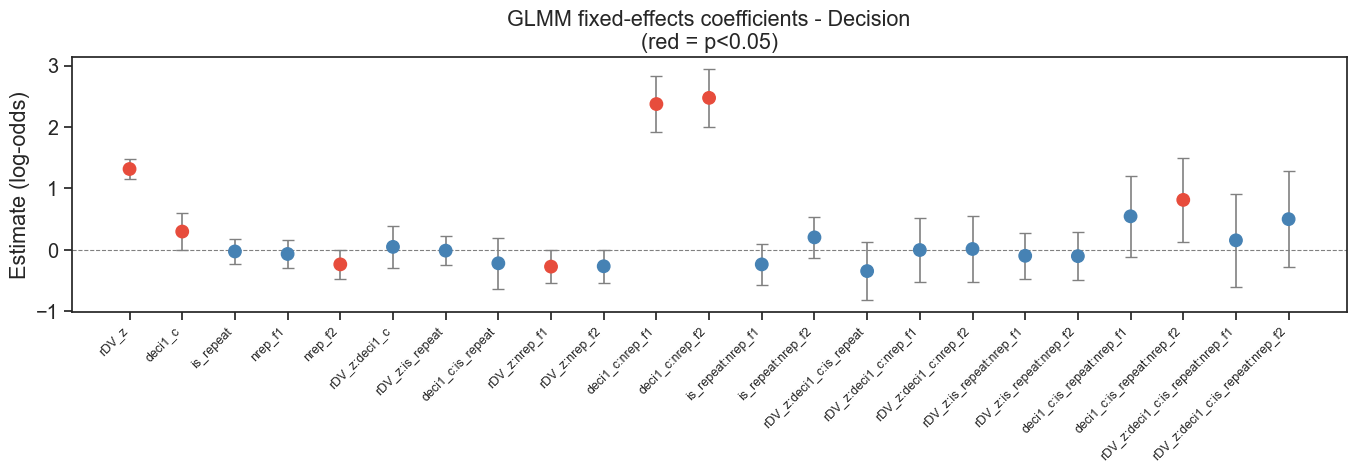

In [18]:
# plot main model 
coefs_plot = coefs_deci_pd[coefs_deci_pd["term"] != "(Intercept)"].copy()
colors = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
ax.scatter(range(len(coefs_plot)), coefs_plot["estimate"],
           color=colors, s=80, zorder=2)
ax.set_xticks(range(len(coefs_plot)))
ax.set_xticklabels(coefs_plot["term"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Estimate (log-odds)")
ax.set_title("GLMM fixed-effects coefficients - Decision\n(red = p<0.05)")
plt.tight_layout()
plt.show()

In [19]:
# GLMM switch --> queremos ver si la probabilidad de cambiar la decision (switch=1) se ve afectada por el numero de repeticion (nrep), el tipo de trial (is_repeat) y su interaccion, mientras controlamos por la variabilidad entre sujetos (1|subj)
# switch ~ nrep * is_repeat + (1|subj)

md_switch = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

# convertimos el intercepto del modelo (es decir, la situacion inicial cuando todo el resto es cero) de switch a probabilidad para interpretar la probabilidad base de cambiar la decision (switch=1) sin tener en cuenta los efectos de nrep o is_repeat, es decir, la probabilidad de cambiar la decision en el primer trial (nrep=0) y en un trial no-repeat (is_repeat=0)
intercept   = coefs_switch_pd.loc[coefs_switch_pd["term"]=="(Intercept)", "estimate"].values[0]
p_switch    = 1 / (1 + np.exp(-intercept))
print(f"\nBaseline p(switch decision): {p_switch:.3f}")
print(f"Baseline p(repeat decision): {1-p_switch:.3f}")

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ -0.372088 ┆ 0.078511  ┆ -0.525967 ┆ -0.218208 ┆ -4.739292 ┆ inf ┆ 0.000002   │
│ nrep           ┆ -0.857399 ┆ 0.055437  ┆ -0.966054 ┆ -0.748743 ┆ -15.46608 ┆ inf ┆ 5.8779e-54 │
│ is_repeat      ┆ 0.075086  ┆ 0.082938  ┆ -0.087469 ┆ 0.237642  ┆ 0.905334  ┆ inf ┆ 0.365289   │
│ nrep:is_repeat ┆ -0.178995 ┆ 0.080628  ┆ -0.337023 ┆ -0.020967 ┆ -2.220008 ┆ inf ┆ 0.026418   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘

Basel

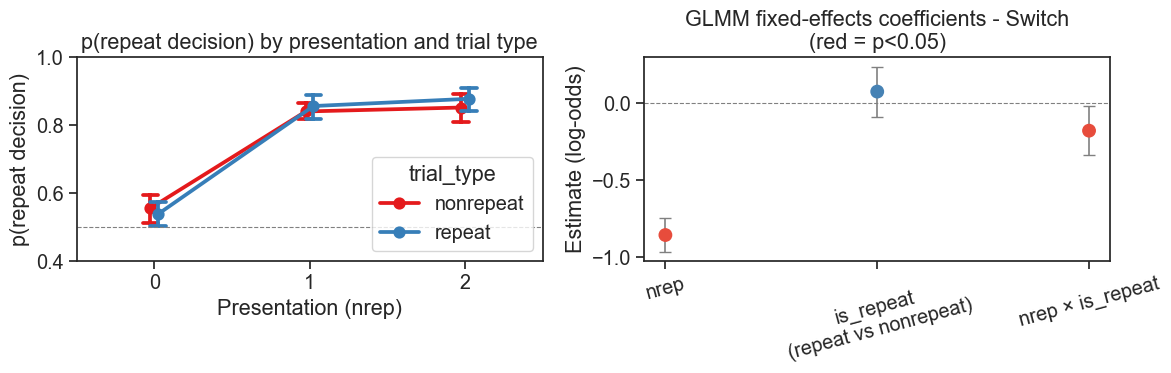


interpretation:
  nrep                      β=-0.8574  p=0.0000  → SIGNIFICATIVO
  is_repeat                 β=+0.0751  p=0.3653  → n.s.
  nrep:is_repeat            β=-0.1790  p=0.0264  → SIGNIFICATIVO


In [20]:
# plot Switch 
avg_switch = df_rep.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy()
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by presentation and trial type")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.4, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients - Switch\n(red = p<0.05)")
plt.tight_layout()
plt.show()

print("\ninterpretation:")
for _, row in coefs_sw_plot.iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [21]:
# GLMM switch + sensory evidence --> queremos ver si la probabilidad de cambiar la decision (switch=1) se ve afectada por la evidencia sensorial (rDV_z), el numero de repeticion (nrep), el tipo de trial (is_repeat) y sus interacciones, mientras controlamos por la variabilidad entre sujetos (1|subj)
# switch ~ rDV_z * nrep * is_repeat + (1|subj)

md_switch = glmer(
    "switch ~ rDV_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

intercept = coefs_switch_pd.loc[coefs_switch_pd["term"] == "(Intercept)", "estimate"].values[0]
p_switch  = 1 / (1 + np.exp(-intercept))
print(f"\nBaseline p(switch decision): {p_switch:.3f}")
print(f"Baseline p(repeat decision): {1 - p_switch:.3f}")

print("\nefectos significativos (p < 0.05):")
sig_sw = coefs_switch_pd[coefs_switch_pd["p_value"] < 0.05]
for _, row in sig_sw.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

shape: (8, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬────────────┬─────┬────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat     ┆ df  ┆ p_value    │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ --- ┆ ---        │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64 ┆ f64        │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪═════╪════════════╡
│ (Intercept)      ┆ -0.375073 ┆ 0.078794  ┆ -0.529507 ┆ -0.220639 ┆ -4.760143  ┆ inf ┆ 0.000002   │
│ rDV_z            ┆ -0.11963  ┆ 0.059145  ┆ -0.235552 ┆ -0.003708 ┆ -2.022657  ┆ inf ┆ 0.043109   │
│ nrep             ┆ -0.861386 ┆ 0.05576   ┆ -0.970674 ┆ -0.752099 ┆ -15.448097 ┆ inf ┆ 7.7704e-54 │
│ is_repeat        ┆ 0.078793  ┆ 0.08306   ┆ -0.084001 ┆ 0.241588  ┆ 0.94863    ┆ inf ┆ 0.342809   │
│ rDV_z:nrep       ┆ -0.015633 ┆ 0.05582   ┆ -0.125038 ┆ 0.093771  ┆ -0.28006

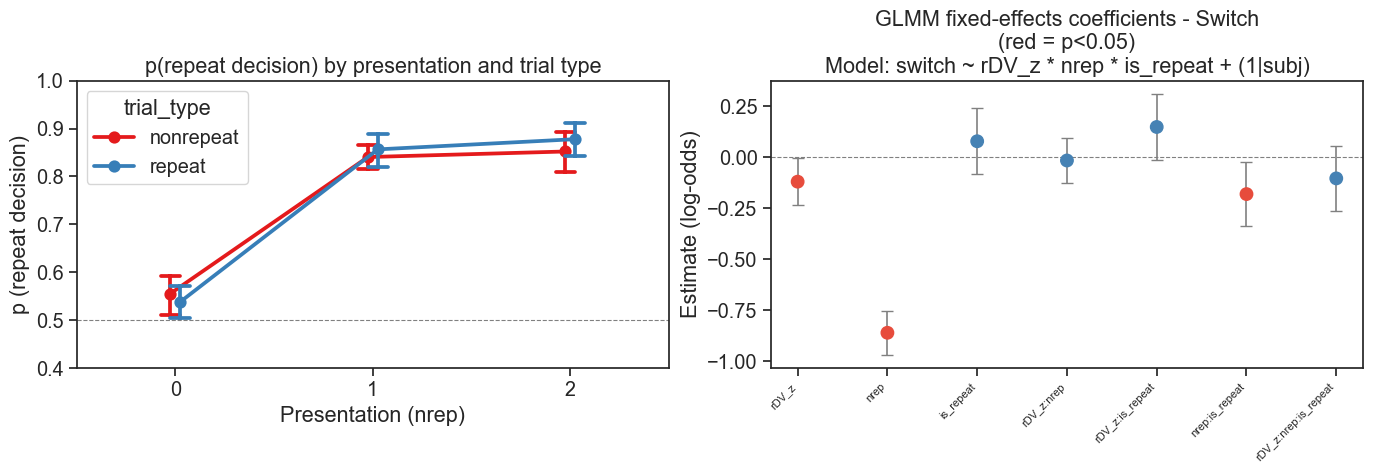


Interpretation:
  rDV_z                               β=-0.1196  p=0.0431  → SIGNIFICANT
  nrep                                β=-0.8614  p=0.0000  → SIGNIFICANT
  is_repeat                           β=+0.0788  p=0.3428  → n.s.
  rDV_z:nrep                          β=-0.0156  p=0.7794  → n.s.
  rDV_z:is_repeat                     β=+0.1488  p=0.0741  → n.s.
  nrep:is_repeat                      β=-0.1806  p=0.0259  → SIGNIFICANT
  rDV_z:nrep:is_repeat                β=-0.1035  p=0.2017  → n.s.


In [22]:
# plot switch 
avg_switch = df_rep.groupby(["subj", "nrep", "trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy().reset_index(drop=True)
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by presentation and trial type")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p (repeat decision)")
axes[0].set_ylim(0.4, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(coefs_sw_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients - Switch\n(red = p<0.05)\nModel: switch ~ rDV_z * nrep * is_repeat + (1|subj)")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in coefs_sw_plot.iterrows():
    sig = "SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [23]:
# GLMM confidence - switch --> queremos ver si la probabilidad de cambiar la decision (switch=1) se ve afectada por la confianza del trial anterior (confi-1), el numero de repeticion (nrep), el tipo de trial (is_repeat) y sus interacciones, mientras controlamos por la variabilidad entre sujetos (1|subj)
# switch ~ confi1_z * nrep * is_repeat + (1|subj)

df_confi = df_rt[df_rt["nrep"] > 0].copy() # nos quedamos solo con los trials de nrep 1 y 2, porque el trial de nrep=0 no tiene un trial anterior con confianza (confi-1) que podamos usar como predictor, ya que es la primera presentacion del estimulo
df_confi = df_confi.dropna(subset=["confi-1"]).reset_index(drop=True)
df_confi["confi1_z"] = df_confi.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std()) # por participante estandarizamos la confianza del trial anterior (confi-1) para que tenga media 0 y desviacion estandar 1, lo que facilita la interpretacion de los coeficientes del modelo y reduce el impacto de diferencias individuales en la escala de confianza

print(f"Trials: {len(df_confi)} | Participants: {df_confi['subj'].nunique()}")

md_confi = glmer(
    "switch ~ confi1_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_confi),
    family="binomial"
)
md_confi.fit()

coefs_confi    = md_confi.result_fit
coefs_confi_pd = coefs_confi.to_pandas()
print(coefs_confi)

print("\ninterpretation:")
for _, row in coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4370 | Participants: 25
shape: (8, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ -2.213715 ┆ 0.256092  ┆ -2.715646 ┆ -1.711784 ┆ -8.644216 ┆ inf ┆ 5.4176e-18 │
│ confi1_z          ┆ -0.977478 ┆ 0.211207  ┆ -1.391436 ┆ -0.56352  ┆ -4.628055 ┆ inf ┆ 0.000004   │
│ nrep              ┆ 0.145381  ┆ 0.138572  ┆ -0.126216 ┆ 0.416978  ┆ 1.049134  ┆ inf ┆ 0.294117   │
│ is_repeat         ┆ 0.191185  ┆ 0.327877  ┆ -0.451443 ┆ 0.833812  ┆ 0.583099  ┆ inf ┆ 0.559827   │
│ confi1_z:nrep     ┆ 0.182223  ┆ 0.134097  ┆

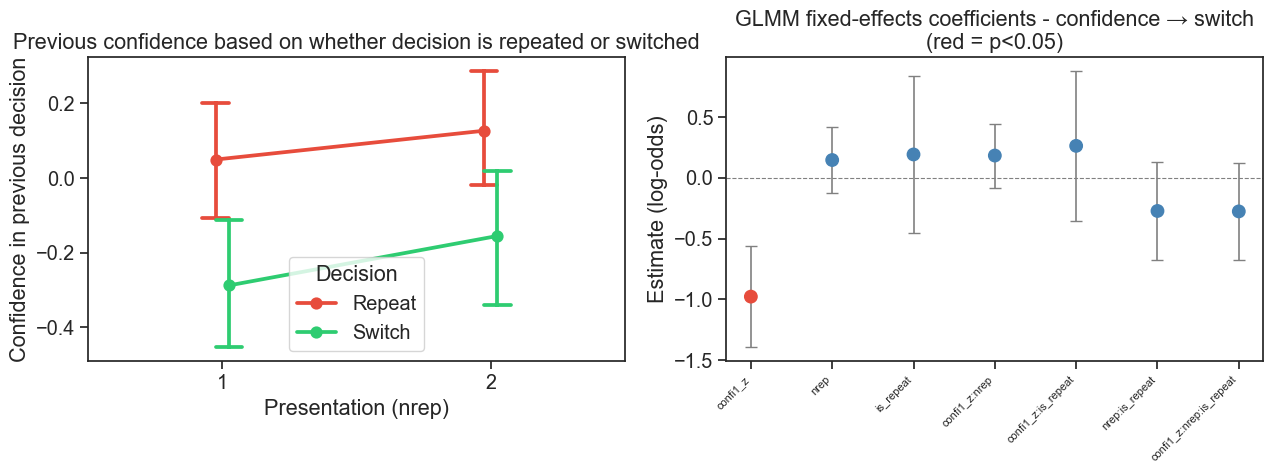

In [24]:
# plot confidence - switch
avg_confi_switch = df_confi.groupby(
    ["subj", "nrep", "switch"], as_index=False
)["confi-1"].mean()
coefs_cf_plot = coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].copy()
colors_cf     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_cf_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(data=avg_confi_switch, x="nrep", y="confi-1", hue="switch",
              dodge=True, capsize=0.1,
              palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[0])
axes[0].set_title("Previous confidence based on whether decision is repeated or switched")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("Confidence in previous decision")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Repeat", "Switch"], title="Decision")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_cf_plot)),
    y=coefs_cf_plot["estimate"],
    yerr=[coefs_cf_plot["estimate"] - coefs_cf_plot["conf_low"],
          coefs_cf_plot["conf_high"] - coefs_cf_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_cf_plot)), coefs_cf_plot["estimate"],
                color=colors_cf, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_cf_plot)))
axes[1].set_xticklabels(coefs_cf_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients - confidence → switch\n(red = p<0.05)")
plt.tight_layout()
plt.show()

In [25]:
# stimulus weights --> queremos ver si la decision (deci) se ve afectada por la decision anterior (deci1_c), la evidencia sensorial de cada uno de los 6 elementos del estimulo (d1_z a d6_z), el numero de presentacion (nrep) y el tipo de trial (is_repeat), mientras controlamos por la variabilidad entre sujetos (1|subj)
# es decir, cuanto peso tiene cada orientacion individual (d1...d6) en la decision del participante y si ese peso cambia con las repeticiones o la decision anterior o el tipo de trial
# deci ~ deci1_c + d1_z + d2_z + d3_z + d4_z + d5_z + d6_z + (1|subj) per nrep

for col in ["d1","d2","d3","d4","d5","d6"]:
    df_rep[f"{col}_z"] = df_rep.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

results_stim = []

for nrep_val in [1, 2]: # cogemos solo nrep 1 y 2 porque el nrep=0 no tiene una decision anterior (deci-1) 
    dat = df_rep[df_rep["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci1_c + d1_z + d2_z + d3_z + d4_z + d5_z + d6_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val # añadimos una columna "nrep" para indicar a que numero de presentacion corresponde cada fila
    results_stim.append(res)

df_coefs_stim = pd.concat(results_stim, ignore_index=True)
print(df_coefs_stim[["nrep","term","estimate","p_value"]].round(4))

    nrep         term  estimate  p_value
0      1  (Intercept)    0.1967   0.0868
1      1      deci1_c    2.9692   0.0000
2      1         d1_z    0.4379   0.0000
3      1         d2_z    0.3126   0.0000
4      1         d3_z    0.3786   0.0000
5      1         d4_z    0.3721   0.0000
6      1         d5_z    0.4181   0.0000
7      1         d6_z    0.3151   0.0000
8      2  (Intercept)    0.2433   0.0391
9      2      deci1_c    3.1250   0.0000
10     2         d1_z    0.2830   0.0000
11     2         d2_z    0.4229   0.0000
12     2         d3_z    0.4113   0.0000
13     2         d4_z    0.3485   0.0000
14     2         d5_z    0.3488   0.0000
15     2         d6_z    0.4340   0.0000


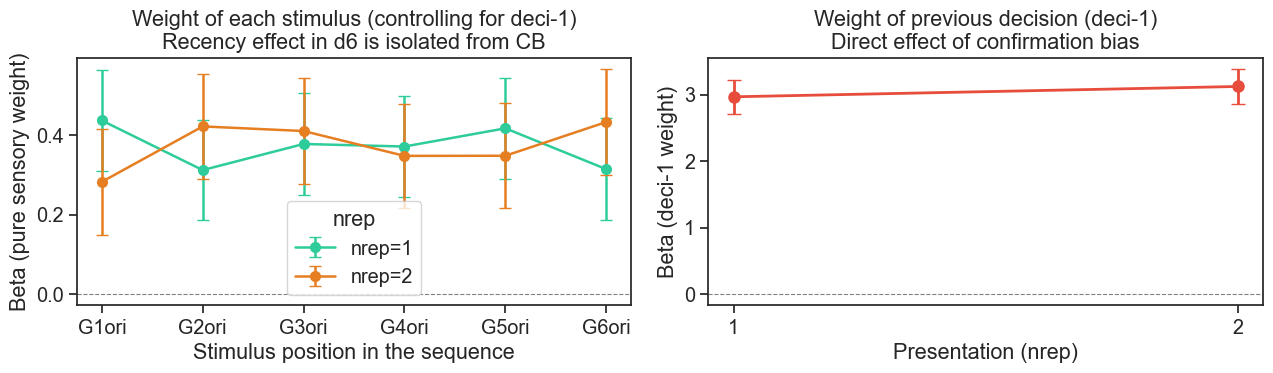

test deci-1 weight:
  nrep=1: β=+2.9692  p=0.0000  → SIGNIFICANT
  nrep=2: β=+3.1250  p=0.0000  → SIGNIFICANT


In [26]:
# plot stimulus weights 
stim_names = ["d1_z","d2_z","d3_z","d4_z","d5_z","d6_z"]
df_stim = df_coefs_stim[df_coefs_stim["term"].isin(stim_names)].copy()
df_deci = df_coefs_stim[df_coefs_stim["term"] == "deci1_c"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_stim[df_stim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1ori","G2ori","G3ori","G4ori","G5ori","G6ori"])
axes[0].set_xlabel("Stimulus position in the sequence")
axes[0].set_ylabel("Beta (pure sensory weight)")
axes[0].set_title("Weight of each stimulus (controlling for deci-1)\nRecency effect in d6 is isolated from CB")
axes[0].legend(title="nrep")
axes[1].errorbar(
    x=[0, 1], y=df_deci["estimate"],
    yerr=[df_deci["estimate"] - df_deci["conf_low"],
          df_deci["conf_high"] - df_deci["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentation (nrep)")
axes[1].set_ylabel("Beta (deci-1 weight)")
axes[1].set_title("Weight of previous decision (deci-1)\nDirect effect of confirmation bias")
plt.tight_layout()                                                                              
plt.show()
print("test deci-1 weight:")
for _, row in df_deci.iterrows():
    sig = "SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  nrep={row['nrep']}: β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [27]:
# CB index --> queremos crear un indice de confirmacion (CB_idx) que refleje el peso de las orientaciones mas congruentes con la decision anterior (G1sim, G2sim) frente a las orientaciones mas incongruentes (G5sim, G6sim), controlando por la decision anterior (deci-1)
# G1sim = most congruent with prev decision, G6sim = most incongruent
# CB_idx = posw(G1,G2) - negw(G5,G6)

prev_deci     = df_rep["deci-1"].copy().replace({0: -1}) # convertimos los valores de deci-1 de 0 a -1 a -1 a 1
orientations  = df_rep[["d1","d2","d3","d4","d5","d6"]].values
prev_respdiff = orientations * prev_deci.values[:, None] # multiplicamos cada orientacion por la decision anterior (deci-1) para obtener un valor positivo para las orientaciones congruentes con la decision anterior y un valor negativo para las orientaciones incongruentes, lo que nos permite ordenar las orientaciones segun su congruencia con la decision anterior
sort_idx      = prev_respdiff.argsort(axis=1)[:, ::-1] # ordenamos de mayor a menor segun la congruencia
reo_orien     = np.take_along_axis(orientations, sort_idx, axis=1)

reo_df = pd.DataFrame(reo_orien, columns=["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
df_glm = pd.concat([df_rep.reset_index(drop=True), reo_df], axis=1)
df_glm["deci_prev"] = prev_deci.values

for col in ["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"]:
    df_glm[f"{col}_z"] = df_glm.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

sim_names    = ["G1sim_z","G2sim_z","G3sim_z","G4sim_z","G5sim_z","G6sim_z"]
results_sim  = []

for nrep_val in [1, 2]:
    dat = df_glm[df_glm["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci_prev + G1sim_z + G2sim_z + G3sim_z + G4sim_z + G5sim_z + G6sim_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val
    results_sim.append(res)

df_coefs_sim = pd.concat(results_sim, ignore_index=True)

print("CB index by nrep:")
for nrep_val in [1, 2]:
    d    = df_coefs_sim[df_coefs_sim["nrep"] == nrep_val]
    posw = d[d["term"].isin(["G1sim_z","G2sim_z"])]["estimate"].mean()
    negw = d[d["term"].isin(["G5sim_z","G6sim_z"])]["estimate"].mean()
    cb   = posw - negw # el indice de confirmacion se calcula como la diferencia entre el peso medio de las orientaciones mas congruentes (G1sim_z, G2sim_z) y el peso medio de las orientaciones mas incongruentes (G5sim_z, G6sim_z), lo que refleja la tendencia a favorecer la evidencia que confirma la decision anterior frente a la evidencia que la contradice
    print(f"  nrep={nrep_val}: posw={posw:.4f}, negw={negw:.4f}, CB_idx={cb:.4f}")

CB index by nrep:
  nrep=1: posw=-0.0567, negw=0.2773, CB_idx=-0.3340
  nrep=2: posw=-0.0356, negw=0.4920, CB_idx=-0.5277


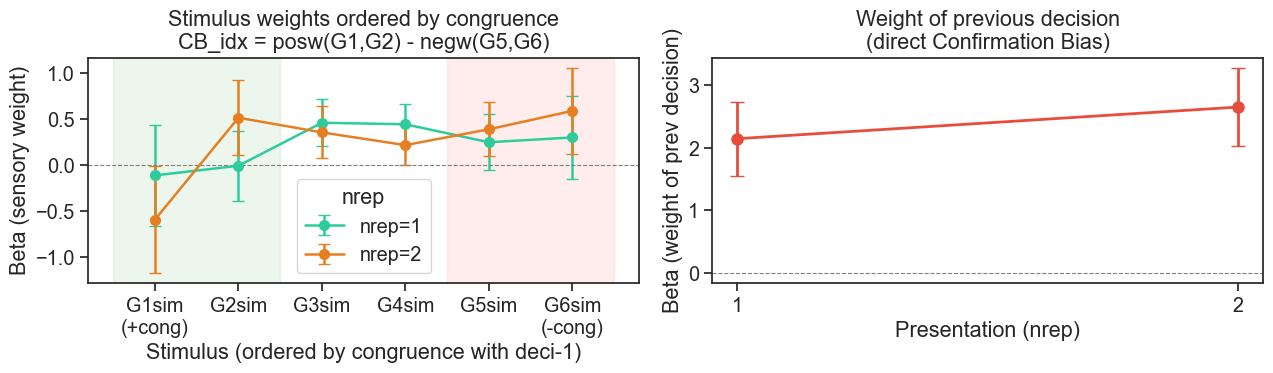

In [28]:
# plot CB Index 
df_sim = df_coefs_sim[df_coefs_sim["term"].isin(sim_names)].copy()
df_dp  = df_coefs_sim[df_coefs_sim["term"] == "deci_prev"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_sim[df_sim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1sim\n(+cong)","G2sim","G3sim","G4sim","G5sim","G6sim\n(-cong)"])
axes[0].set_xlabel("Stimulus (ordered by congruence with deci-1)")
axes[0].set_ylabel("Beta (sensory weight)")
axes[0].set_title("Stimulus weights ordered by congruence\nCB_idx = posw(G1,G2) - negw(G5,G6)")
axes[0].legend(title="nrep")
axes[0].axvspan(-0.5, 1.5, alpha=0.07, color="green")
axes[0].axvspan(3.5, 5.5, alpha=0.07, color="red")

axes[1].errorbar(
    x=[0, 1], y=df_dp["estimate"],
    yerr=[df_dp["estimate"] - df_dp["conf_low"],
          df_dp["conf_high"] - df_dp["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentation (nrep)")
axes[1].set_ylabel("Beta (weight of prev decision)")
axes[1].set_title("Weight of previous decision\n(direct Confirmation Bias)")
plt.tight_layout()
plt.show()

In [29]:
# GLMM stubbornness --> queremos ver si la probabilidad de cambiar la decision (switch=1) se ve afectada por el numero de repeticion (nrep), el tipo de trial (is_repeat) y su interaccion, pero solo en los trials donde la decision anterior fue incorrecta (correct-1 == 0), lo que nos permite aislar el efecto de la terquedad, es decir, la tendencia a mantener una decision incorrecta a pesar de la evidencia en contra
# es decir, si cuando un participante cometio un error en la decision anterior, sigue manteniendo esa decision en el siguiente trial?
# Trials where correct-1 == 0 (previous error only)
# switch ~ nrep * is_repeat + (1|subj)

df_err = df_rep[df_rep["correct-1"] == 0].copy() # nos quedamos solo con los trials donde la decision anterior fue incorrecta (correct-1 == 0)

print(f"Trials with previous error : {len(df_err)}")
print(f"Global mean stubbornness   : {(1 - df_err['switch'].mean()):.3f}") # p(stubbornness) = 1 - p(switch | correct-1 = 0)
print()
print("Stubbornness by condition (p(no switch | previous error)):")
print(df_err.groupby(["nrep","trial_type"])["switch"].apply(
    lambda x: (1 - x.mean())).round(3)) 

md_stub = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_err),
    family="binomial"
)
md_stub.fit()

coefs_stub    = md_stub.result_fit
coefs_stub_pd = coefs_stub.to_pandas()
print(coefs_stub)

intercept_stub = coefs_stub_pd.loc[coefs_stub_pd["term"]=="(Intercept)", "estimate"].values[0]
p_stub = 1 / (1 + np.exp(-intercept_stub))
print(f"\np(NO switch | previous error): {1-p_stub:.3f}")
print(f"participants maintain their incorrect decision {(1-p_stub)*100:.1f}% of the times")

Trials with previous error : 1786
Global mean stubbornness   : 0.675

Stubbornness by condition (p(no switch | previous error)):
nrep  trial_type
0     nonrepeat     0.545
      repeat        0.589
1     nonrepeat     0.687
      repeat        0.746
2     nonrepeat     0.704
      repeat        0.771
Name: switch, dtype: float64
shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬──────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value  │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---      │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64      │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪══════════╡
│ (Intercept)    ┆ -0.252508 ┆ 0.122579  ┆ -0.492758 ┆ -0.012258 ┆ -2.059966 ┆ inf ┆ 0.039402 │
│ nrep           ┆ -0.361483 ┆ 0.088658  ┆ -0.535248 ┆ -0.187717 ┆ -4.077288 ┆ 

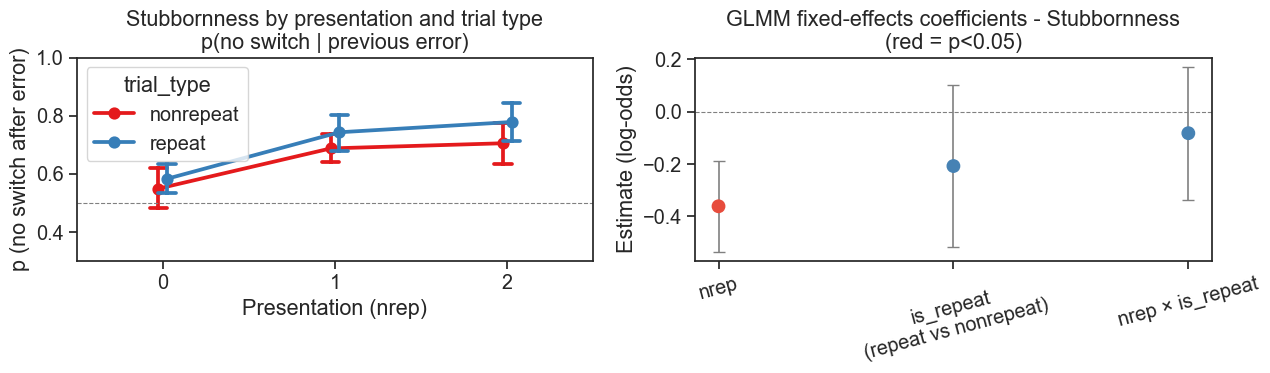


interpretation:
  nrep                      β=-0.3615  p=0.0000  → SIGNIFICATIVO
  is_repeat                 β=-0.2077  p=0.1883  → n.s.
  nrep:is_repeat            β=-0.0822  p=0.5254  → n.s.


In [30]:
# plot stubbornness 
avg_stub = df_err.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_stub["stubbornness"] = 1 - avg_stub["switch"] # p(stubbornness) = 1 - p(switch | correct-1 = 0)

coefs_st_plot = coefs_stub_pd[coefs_stub_pd["term"] != "(Intercept)"].copy()
colors_st     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_st_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.pointplot(data=avg_stub, x="nrep", y="stubbornness", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
axes[0].set_title("Stubbornness by presentation and trial type\np(no switch | previous error)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p (no switch after error)")
axes[0].set_ylim(0.3, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_st_plot)),
    y=coefs_st_plot["estimate"],
    yerr=[coefs_st_plot["estimate"] - coefs_st_plot["conf_low"],
          coefs_st_plot["conf_high"] - coefs_st_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_st_plot)), coefs_st_plot["estimate"],
                color=colors_st, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_st_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients - Stubbornness\n(red = p<0.05)")
plt.tight_layout()
plt.show()

print("\ninterpretation:")
for _, row in coefs_st_plot.iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [ ]:
# GLMM global metacognition --> queremos ver si la probabilidad de tomar una decision correcta (correct=1) se ve afectada por la eficiencia metacognitiva (metad_eff), la decision anterior (correct_prev) y el numero de repeticion (nrep), mientras controlamos por la variabilidad entre sujetos (1|subj)
# es decir, los participantes con mejor metacognicion (los mas conscientes de sus errores) muestran menos CB? 
# saber cuando te equivocas te ayuda a no repetir el error?
# correct ~ nrep * metad_eff + correct_prev + (1|subj)

df0 = df_rt[df_rt["nrep"] == 0].copy() # cogemos solo los trials de nrep=0 para calcular la d', porque es la situacion inicial antes de cualquier repeticion, lo que nos permite obtener una medida de la capacidad de discriminacion del participante sin la influencia de las repeticiones o el tipo de trial

def calc_dprime(x): # la d' es como de bien distingues señal de ruido, es decir, los trials donde la condicion es 1 (señal) frente a los trials donde la condicion es 0 (ruido)
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum() # los hits son los casos donde el participante decidio 1 (deci=1) y la condicion era 1 (cond=1) --> respuesta correcta en trials de señal
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum() # los false alarms son los casos donde el participante decidio 1 (deci=1) pero la condicion era 0 (cond=0) --> respuesta incorrecta en trials de ruido
    noise  = (x["cond"] == 0).sum() # el numero de casos donde la condicion era 0 (cond=0)
    signal = (x["cond"] == 1).sum() # el numero de casos donde la condicion era 1 (cond=1)
    hr  = (hits + 0.5) / (signal + 1) # la tasa de aciertos se calcula como el numero de hits dividido por el numero total de trials de señal (signal) --> se le añade 0.5 al numerador y 1 al denominador para evitar tener una tasa de aciertos de 0 o 1, lo que haria que la d' sea infinita o indefinida
    far = (fa   + 0.5) / (noise  + 1) # la tasa de falsas alarmas se calcula como el numero de false alarms dividido por el numero total de trials de ruido (noise) --> se le añade 0.5 al numerador y 1 al denominador para evitar tener una tasa de falsas alarmas de 0 o 1, lo que haria que la d' sea infinita o indefinida
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)}) # la d' se calcula como la diferencia entre la tasa de aciertos (hr) y la tasa de falsas alarmas (far), lo que refleja la capacidad del participante para distinguir entre los trials de señal y ruido, independientemente de su sesgo de respuesta

dprime_df  = df0.groupby("subj").apply(calc_dprime, include_groups=False).reset_index() # calculamos d' para cada participante

# la meta d' es que tan bien usa el participante su confianza para distinguir sus aciertos de sus errores
metad_subj = df_rt.groupby("subj")["metad"].first().reset_index() # cogemos el valor de metad por participante (es el mismo para todos los trials de un mismo participante, por eso usamos .first())
eff_df     = metad_subj.merge(dprime_df, on="subj") # unimos la d' con la meta d' por participante p
eff_df["metad_eff"] = eff_df["metad"] / eff_df["dprime"] # la eficiencia metacognitiva se calcula como la meta d' dividida por la d'

df_meta = df_rt[df_rt["nrep"] > 0].copy() 
df_meta = df_meta.rename(columns={"correct-1": "correct_prev"})
df_meta["correct_prev"] = df_meta["correct_prev"].astype(float)
df_meta = df_meta.merge(eff_df[["subj", "metad_eff"]], on="subj")
df_meta["metad_eff_z"] = (df_meta["metad_eff"] - df_meta["metad_eff"].mean()) / df_meta["metad_eff"].std() # estandarizamos
df_meta = df_meta.dropna(subset=["correct", "correct_prev", "metad_eff_z"]).reset_index(drop=True)

print(f"Trials: {len(df_meta)} | Participants: {df_meta['subj'].nunique()}")

md_metad = glmer(
    "correct ~ nrep * metad_eff_z + correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta),
    family="binomial"
)
md_metad.fit()

coefs_metad    = md_metad.result_fit
coefs_metad_pd = coefs_metad.to_pandas()
print(coefs_metad)

print("\nInterpretation:")
for _, row in coefs_metad_pd.iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4195 | Participants: 24
shape: (5, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept)      ┆ -0.994264 ┆ 0.152329  ┆ -1.292822 ┆ -0.695705 ┆ -6.527099 ┆ inf ┆ 6.7056e-11  │
│ nrep             ┆ 0.007811  ┆ 0.090589  ┆ -0.169739 ┆ 0.185362  ┆ 0.086229  ┆ inf ┆ 0.931285    │
│ metad_eff_z      ┆ 0.233873  ┆ 0.145479  ┆ -0.05126  ┆ 0.519007  ┆ 1.607608  ┆ inf ┆ 0.107921    │
│ correct_prev     ┆ 3.252261  ┆ 0.091093  ┆ 3.073722  ┆ 3.430801  ┆ 35.702541 ┆ inf ┆ 3.6101e-279 │
│ nrep:metad_eff_z ┆ -0.126744 ┆ 0.090617  ┆ 

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_79342/1132783522.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta_global = df_meta.groupby(


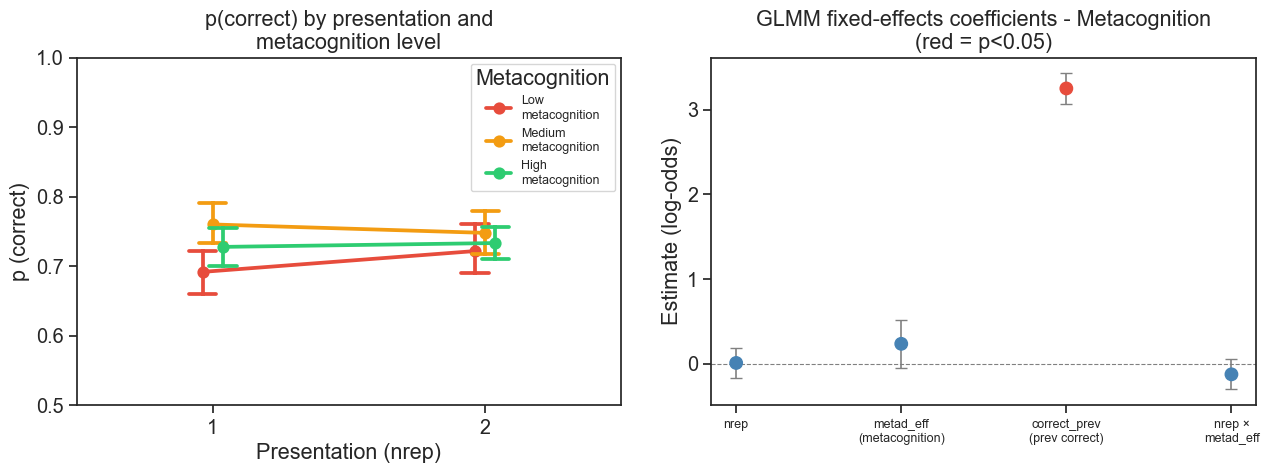

In [32]:
# plot global metacognition 

df_meta["metad_eff_bin"] = pd.qcut(
    df_meta["metad_eff_z"], q=3, # dividimos la eficiencia metacognitiva estandarizada en 3 grupos para crear una variable que nos permita comparar el rendimiento entre participantes con baja, media y alta eficiencia metacognitiva
    labels=["Low\nmetacognition", "Medium\nmetacognition", "High\nmetacognition"]
)

avg_meta_global = df_meta.groupby(
    ["subj", "nrep", "metad_eff_bin"], as_index=False
)["correct"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.pointplot(
    data=avg_meta_global, x="nrep", y="correct",
    hue="metad_eff_bin", dodge=True, capsize=0.1,
    palette={"Low\nmetacognition": "#e74c3c",
             "Medium\nmetacognition": "#f39c12",
             "High\nmetacognition": "#2ecc71"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(correct) by presentation and\nmetacognition level")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p (correct)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Metacognition", fontsize=9)

coefs_plot = coefs_metad_pd[coefs_metad_pd["term"] != "(Intercept)"].copy()
colors_m   = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_plot)), coefs_plot["estimate"],
                color=colors_m, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "metad_eff\n(metacognition)", "correct_prev\n(prev correct)", "nrep ×\nmetad_eff"],
    fontsize=9)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients - Metacognition\n(red = p<0.05)")

plt.tight_layout()
plt.show()

In [33]:
# GLMM trial-by-trial metacognition --> queremos ver si la probabilidad de tomar una decision correcta (correct=1) se ve afectada por la decision anterior (deci-1), la confianza del trial anterior (confi-1) y su interaccion, mientras controlamos por la variabilidad entre sujetos (1|subj)
# es decir, el CB es mayor cuando la confianza del trial anterior es alta? 
# deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)

df_rep_meta = df_rt[df_rt["nrep"] > 0].dropna( # filtrar y limpiar
    subset=["deci1_c", "rDV_z", "is_repeat"]
).copy()

df_rep_meta["confi-1"] = df_rep_meta.groupby( # creamos confi-1 agrupando por sujeto
    ["subj", "nblock", "ntrial"]
)["confi"].shift(1)

df_meta_trial = df_rep_meta.dropna(subset=["confi-1"]).copy() # eliminamos los nans de confi-1
df_meta_trial["confi1_z"] = df_meta_trial.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std()) # estandarizamos la confianza del trial anterior (confi-1) por participante para que tenga media 0 y desviacion estandar 1, lo que facilita la interpretacion de los coeficientes del modelo 
df_meta_trial["correct_prev"] = df_meta_trial["correct-1"].astype(float)

print(f"Trials: {len(df_meta_trial)} | Participants: {df_meta_trial['subj'].nunique()}")

md_meta_trial = glmer(
    "deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta_trial),
    family="binomial"
)
md_meta_trial.fit()

coefs_mt    = md_meta_trial.result_fit
coefs_mt_pd = coefs_mt.to_pandas()
print(coefs_mt)

print("\nEfectos significativos:")
for _, row in coefs_mt_pd.iterrows():
    sig = "SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 2170 | Participants: 25
shape: (9, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.186456  ┆ 0.146431  ┆ -0.100543 ┆ 0.473456  ┆ 1.273341  ┆ inf ┆ 0.202897   │
│ rDV_z             ┆ 0.920719  ┆ 0.150526  ┆ 0.625694  ┆ 1.215744  ┆ 6.116686  ┆ inf ┆ 9.5541e-10 │
│ deci1_c           ┆ 3.48546   ┆ 0.313407  ┆ 2.871193  ┆ 4.099726  ┆ 11.12119  ┆ inf ┆ 9.8943e-29 │
│ confi1_z          ┆ 0.030666  ┆ 0.117136  ┆ -0.198917 ┆ 0.260249  ┆ 0.261798  ┆ inf ┆ 0.793477   │
│ correct_prev      ┆ 0.124841  ┆ 0.156244  ┆

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_79342/4135000306.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta = df_meta_trial.groupby(


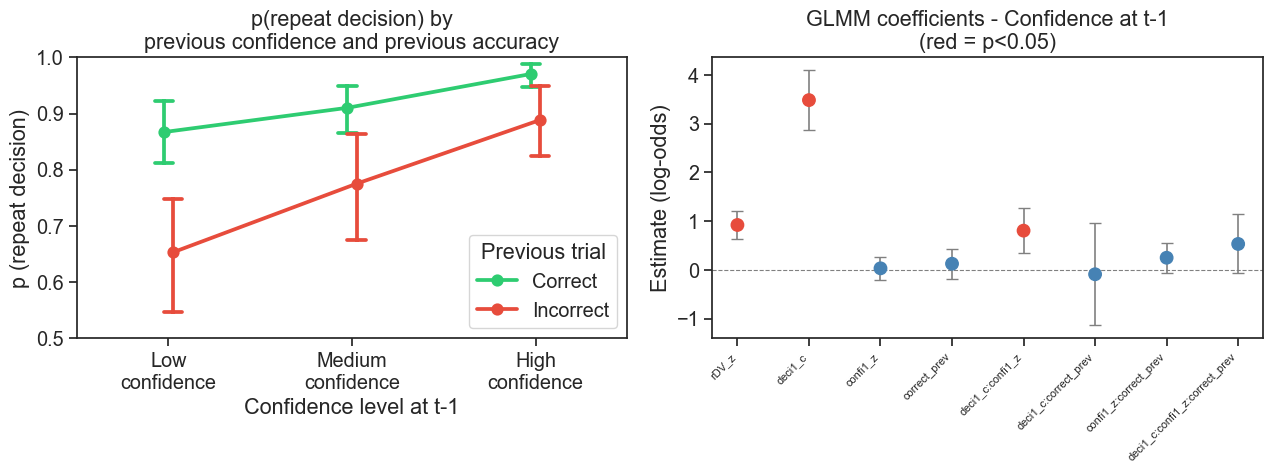

In [34]:
# plot trial-by-trial metacognition 
df_meta_trial["confi1_bin"] = pd.qcut(
    df_meta_trial["confi-1"], q=3,
    labels=["Low\nconfidence", "Medium\nconfidence", "High\nconfidence"])
df_meta_trial["p_repeat"]  = 1 - df_meta_trial["switch"]
df_meta_trial["prev_label"] = df_meta_trial["correct_prev"].map(
    {1.0: "Correct", 0.0: "Incorrect"})
avg_meta = df_meta_trial.groupby(
    ["subj", "confi1_bin", "prev_label"], as_index=False
)["p_repeat"].mean()
coefs_mt_plot = coefs_mt_pd[coefs_mt_pd["term"] != "(Intercept)"].copy()
colors_mt     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_mt_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(
    data=avg_meta, x="confi1_bin", y="p_repeat",
    hue="prev_label", dodge=True, capsize=0.1,
    palette={"Correct": "#2ecc71", "Incorrect": "#e74c3c"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by\nprevious confidence and previous accuracy")
axes[0].set_xlabel("Confidence level at t-1")
axes[0].set_ylabel("p (repeat decision)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Previous trial")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_mt_plot)),
    y=coefs_mt_plot["estimate"],
    yerr=[coefs_mt_plot["estimate"] - coefs_mt_plot["conf_low"],
          coefs_mt_plot["conf_high"] - coefs_mt_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_mt_plot)), coefs_mt_plot["estimate"],
                color=colors_mt, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_mt_plot)))
axes[1].set_xticklabels(coefs_mt_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM coefficients - Confidence at t-1\n(red = p<0.05)")
plt.tight_layout()
plt.show()

En estas celdas que vienen a continuacion se analiza como la meta-d' efficiency se relaciona con la accuracy, separando por :

- Nivel de confianza (alta vs baja)
- Si la respuesta previa era correcta o incorrecta
- Número de presentación (nrep=0, 1, 2)

REPASO DE CONCEPTOS : 

d' --> mide qué tan bien percibes el estímulo
- d' alto → distingues bien cardinal de diagonal
- d' bajo → te cuesta distinguirlos

meta-d' --> qué tan bien sabes cuándo aciertas o fallas
- meta-d' alto → cuando estás seguro, aciertas y cuando dudas, fallas
- meta-d' bajo → tu confianza no predice bien tus aciertos

metad_efficiency = meta-d' / d' --> ratio que compara tu metacognicion con tu percepcion:
- metad_eff = 1.0 → tu metacognición es perfecta → sabes exactamente cuándo aciertas
- metad_eff > 1.0 → metacognición mejor de lo esperado
- metad_eff < 1.0 → metacognición peor de lo esperado → no eres consciente de tus errores

CONFIANZA --> como de seguro estas en cada trial

METACOGNICION --> lo bien calibrada que esta esa seguridad

Previous response: Correct | nrep=0: β=-0.2213  p=0.0000
Previous response: Correct | nrep=1: β=-0.0740  p=0.3846
Previous response: Correct | nrep=2: β=+0.0208  p=0.8369
Previous response: Incorrect | nrep=0: β=-0.2213  p=0.0000
Previous response: Incorrect | nrep=1: β=+0.0919  p=0.3501
Previous response: Incorrect | nrep=2: β=-0.1570  p=0.2552


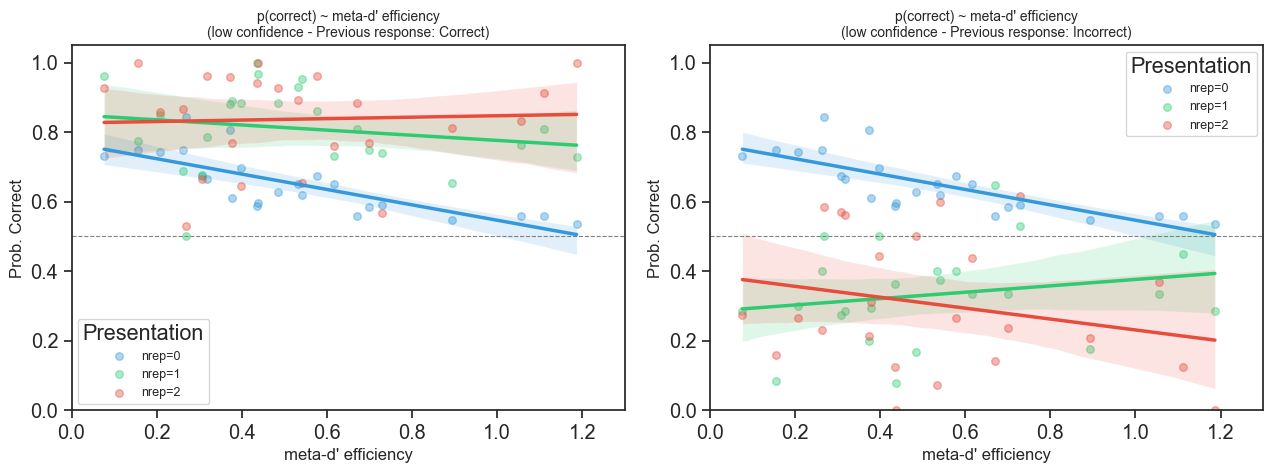

In [35]:
# meta-d' efficiency — low confidence, all nrep 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}
for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Previous response: Correct", "Previous response: Incorrect"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True) # filtrar los NaNs
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj") # unir la eficiencia metacognitiva por participante
        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_low  = df_nrep[df_nrep["confi"] < median_confi].copy() # quedarnos solo con los trials de baja confianza (confi < mediana) 
        if nrep_val == 0:
            df_plot = df_nrep_low.copy() # para nrep=0 no hay decision anterior, asi que no filtramos por correct_prev
        else:
            df_plot = df_nrep_low[df_nrep_low["correct_prev"] == correct_val].copy() # para nrep=1 y nrep=2, filtramos por correct_prev para quedarnos solo con los trials donde la decision anterior fue correcta (correct_prev=1) o incorrecta (correct_prev=0), dependiendo del valor de correct_val en el bucle exterior
        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()
        if len(by_subj) < 3:
            continue
        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )
        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' efficiency\n(low confidence - {title})", fontsize=10)
    ax.legend(title="Presentation", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)
plt.tight_layout()
plt.show()

Previous response: Correct | nrep=0: β=+0.1327  p=0.0013
Previous response: Correct | nrep=1: β=+0.0474  p=0.1527
Previous response: Correct | nrep=2: β=+0.0564  p=0.0418
Previous response: Incorrect | nrep=0: β=+0.1327  p=0.0013
Previous response: Incorrect | nrep=1: β=+0.0569  p=0.6218
Previous response: Incorrect | nrep=2: β=-0.1623  p=0.1424


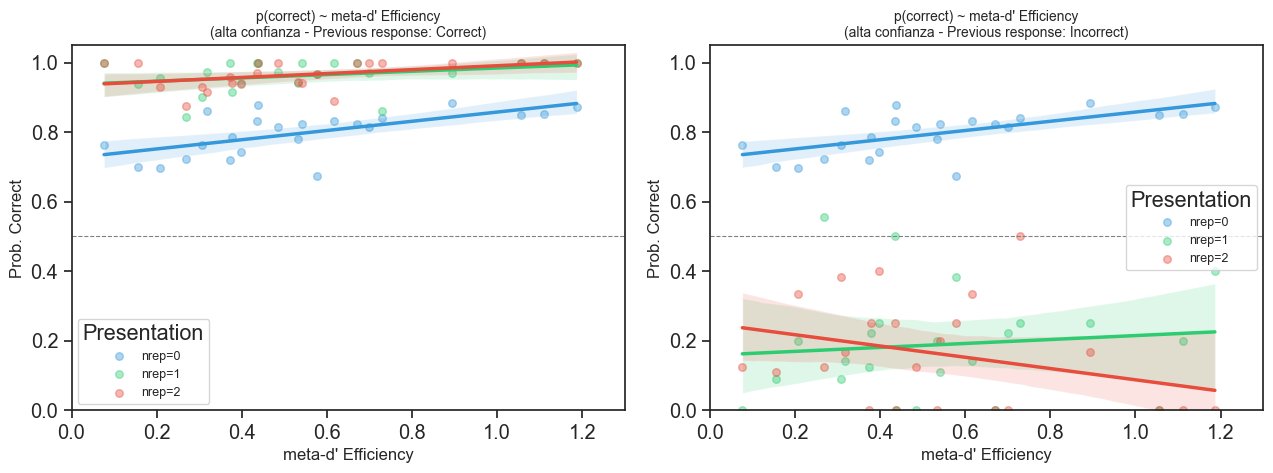

In [36]:
# meta-d' efficiency — high confidence, all nrep 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}

for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Previous response: Correct", "Previous response: Incorrect"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True)
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_high = df_nrep[df_nrep["confi"] > median_confi].copy()

        if nrep_val == 0:
            df_plot = df_nrep_high.copy()
        else:
            df_plot = df_nrep_high[df_nrep_high["correct_prev"] == correct_val].copy()

        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()

        if len(by_subj) < 3:
            continue

        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )

        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' Efficiency\n(alta confianza - {title})", fontsize=10)
    ax.legend(title="Presentation", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)

plt.tight_layout()
plt.show()

nrep=0 (all):  β=-0.2213  r=-0.773  p=0.0000
nrep=1 | Prev Correct  : β=-0.0740  r=-0.186  p=0.3846
nrep=1 | Prev Incorrect: β=+0.0919  r=+0.199  p=0.3501
nrep=2 | Prev Correct  : β=+0.0208  r=+0.044  p=0.8369
nrep=2 | Prev Incorrect: β=-0.1570  r=-0.242  p=0.2552


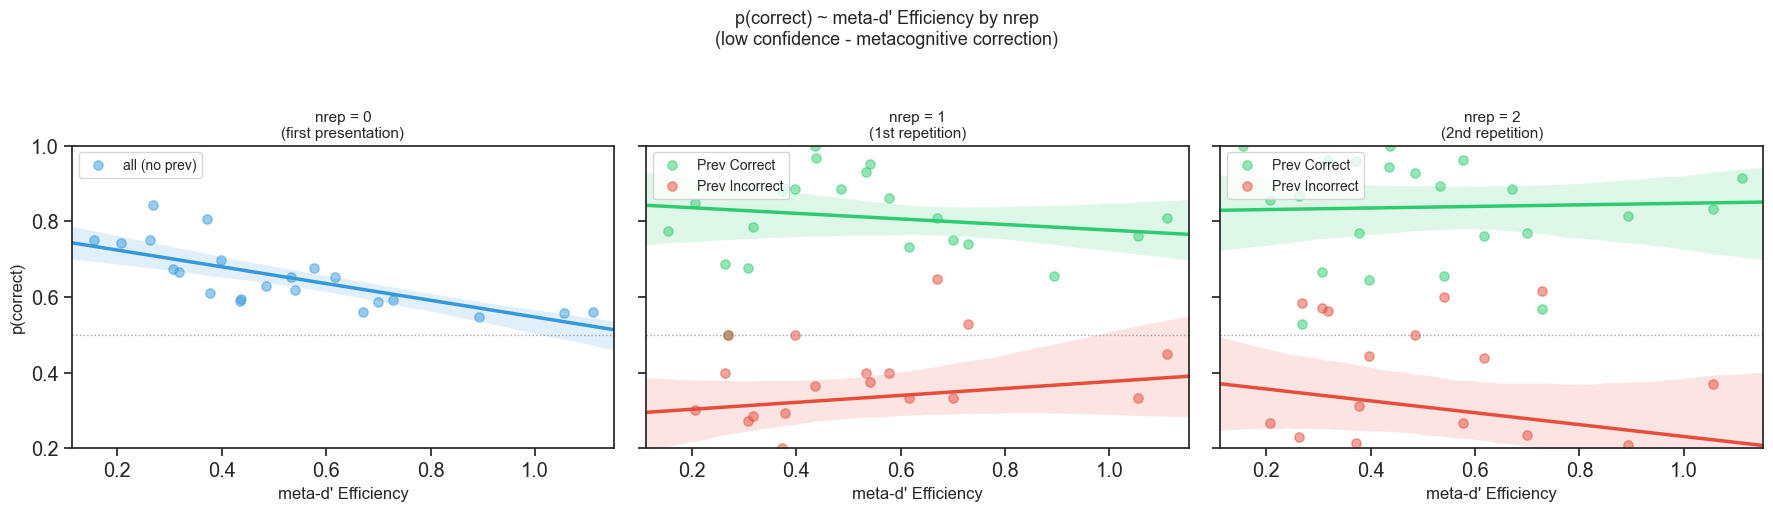

In [37]:
# meta-d' efficiency — low confidence, 3 panels (one per nrep)
# p(correct) ~ metad_efficiency split by previous trial outcome
# low confidence only (confi < per participant median)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}
nrep_titles = {
    0: "nrep = 0\n(first presentation)",
    1: "nrep = 1\n(1st repetition)",
    2: "nrep = 2\n(2nd repetition)",
}

_x = eff_df["metad_eff"].replace([np.inf, -np.inf], np.nan).dropna()
x_lo = np.percentile(_x, 2)
x_hi = np.percentile(_x, 98)

for nrep_val, ax in zip([0, 1, 2], axes):
    df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
    df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
    df_nrep = df_nrep.dropna(subset=["correct", "metad"]).reset_index(drop=True)
    df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

    median_confi = df_nrep.groupby("subj")["confi"].transform("median")
    df_low = df_nrep[df_nrep["confi"] < median_confi].copy()

    if nrep_val == 0:
        by_subj = df_low.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
        if len(by_subj) >= 3:
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color="#3498db", scatter=True, ci=95, n_boot=1000,
                        truncate=True, label="all (no prev)",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5}, ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep=0 (all):  β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")
    else:
        df_low = df_low.dropna(subset=["correct_prev"])
        for label, color in colors.items():
            prev_val = 1.0 if label == "Correct" else 0.0
            d = df_low[df_low["correct_prev"] == prev_val].copy()
            by_subj = d.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
            if len(by_subj) < 3:
                continue
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color=color, scatter=True, ci=95, n_boot=1000,
                        truncate=True, label=f"Prev {label}",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5, "linestyle": "-"},
                        ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep={nrep_val} | Prev {label:<9}: β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("p(correct)" if nrep_val == 0 else "", fontsize=12)
    ax.set_title(nrep_titles[nrep_val], fontsize=11)
    ax.legend(fontsize=10, loc="upper left")

fig.suptitle(
    "p(correct) ~ meta-d' Efficiency by nrep\n"
    "(low confidence - metacognitive correction)",
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.show()


nrep=0 (all):  β=-0.0232  r=-0.336  p=0.1082
nrep=1 | Prev Correct  : β=+0.0106  r=+0.049  p=0.8213
nrep=1 | Prev Incorrect: β=+0.1172  r=+0.253  p=0.2324
nrep=2 | Prev Correct  : β=+0.0377  r=+0.149  p=0.4877
nrep=2 | Prev Incorrect: β=-0.1322  r=-0.243  p=0.2534


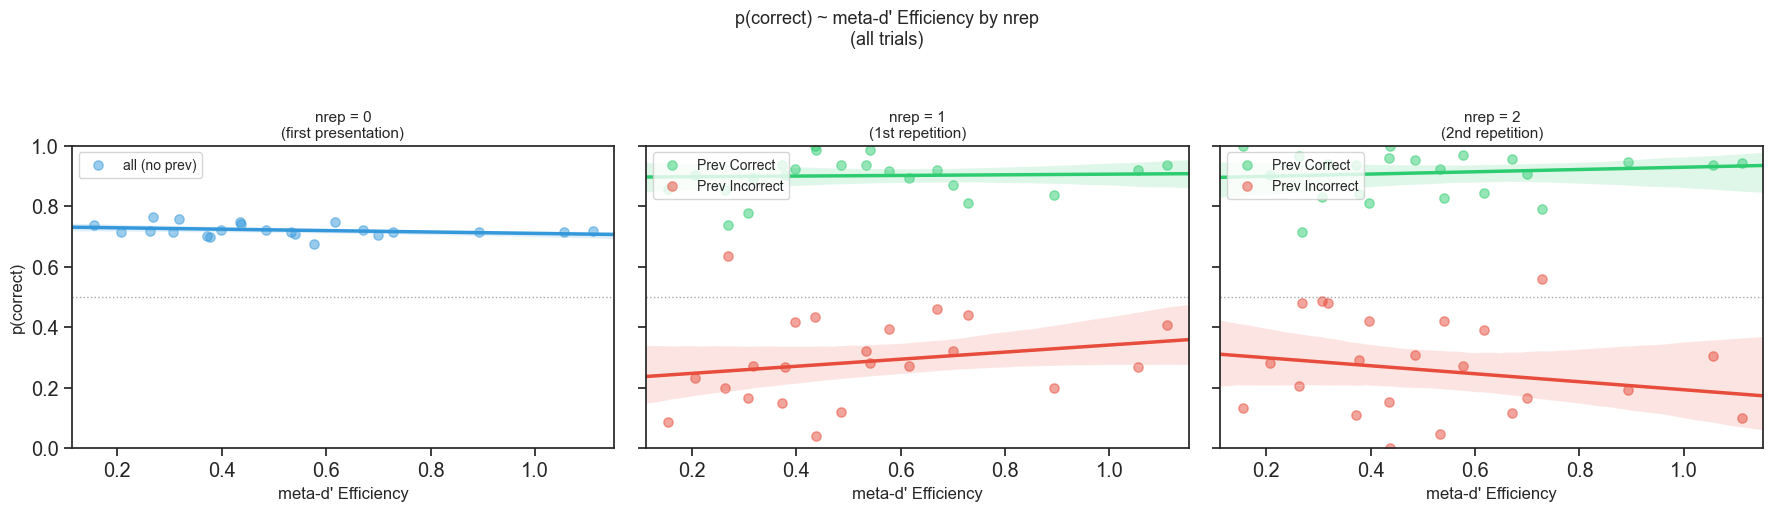

In [38]:
# meta-d' efficiency — all trials, 3 panels (one per nrep) ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}
nrep_titles = {
    0: "nrep = 0\n(first presentation)",
    1: "nrep = 1\n(1st repetition)",
    2: "nrep = 2\n(2nd repetition)",
}

_x = eff_df["metad_eff"].replace([np.inf, -np.inf], np.nan).dropna()
x_lo = np.percentile(_x, 2)
x_hi = np.percentile(_x, 98)

for nrep_val, ax in zip([0, 1, 2], axes):
    df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
    df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
    df_nrep = df_nrep.dropna(subset=["correct", "metad"]).reset_index(drop=True)
    df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

    if nrep_val == 0:
        by_subj = df_nrep.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
        if len(by_subj) >= 3:
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color="#3498db", scatter=True, ci=95, n_boot=1000,
                        truncate=True, label="all (no prev)",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5}, ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep=0 (all):  β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")
    else:
        df_nrep = df_nrep.dropna(subset=["correct_prev"])
        for label, color in colors.items():
            prev_val = 1.0 if label == "Correct" else 0.0
            d = df_nrep[df_nrep["correct_prev"] == prev_val].copy()
            by_subj = d.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
            if len(by_subj) < 3:
                continue
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color=color, scatter=True, ci=95, n_boot=1000,
                        truncate=True, label=f"Prev {label}",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5, "linestyle": "-"},
                        ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep={nrep_val} | Prev {label:<9}: β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("p(correct)" if nrep_val == 0 else "", fontsize=12)
    ax.set_title(nrep_titles[nrep_val], fontsize=11)
    ax.legend(fontsize=10, loc="upper left")

fig.suptitle(
    "p(correct) ~ meta-d' Efficiency by nrep\n"
    "(all trials)",
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.show()